In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

import sys

sys.path.append('../src')

from Config.config import PATHS

import warnings
warnings.filterwarnings("ignore")

In [35]:
from Utils.interaction import Performer
from Utils.utils import GetMeasurements
from Classes.cognitive_model_agents import FocalRegionAgent

### Simulation with different number of schemata

In [ ]:
free_parameters = {
    'inverse_temperature': 8,
    'learning_rate': 0.2,
    'bias': 1,
    'forget': 0.8,
    'len_history': 2,
    'delta': 0.4,
    'max_regions': 3,
}

simulation_parameters = {
    'num_rounds': 20,
    'num_episodes': 100,
    'verbose': False
}
df_list = []

list_fixed_parameters = [
    (2, 0.5),
    (3, 1/3), (3, 2/3),
    (4, 1/4), (4, 0.5), (4, 3/4),
    (5, 2/5), (5, 3/5), (5, 4/5),
    (6, 2/6), (6, 0.5), (6, 4/6),
    (8, 3/8), (8, 5/8), (8, 7/8),
]

In [37]:
for max_regions in tqdm([1, 3, 6], desc='max_regions'):
    for num_agents, threshold in tqdm(
        list_fixed_parameters,
        desc=f'regions={max_regions}',
        leave=False,
    ):
        fixed_parameters = {
            'num_agents': num_agents,
            'threshold': threshold,
        }
        model_class = FocalRegionAgent
        df = Performer.sim(
            agent_class=model_class,
            fixed_parameters=fixed_parameters,
            free_parameters=free_parameters,
            simulation_parameters=simulation_parameters,
        )
        # df['model'] = model_class.name()
        df['model'] = f"{max_regions}"
        df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
df['bounded_score'] = df['score'] / df['threshold']
df.head(2)

max_regions:   0%|          | 0/3 [00:00<?, ?it/s]

regions=1:   0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

FileNotFoundError: Focal regions file /Users/edgar/Documents/GitHub/Cognitive_Models_El_Farol_Bar_Problem/data/focal_regions/_8_agents_0.25_threshold.json does not exist.

<Axes: xlabel='round', ylabel='bounded_score'>

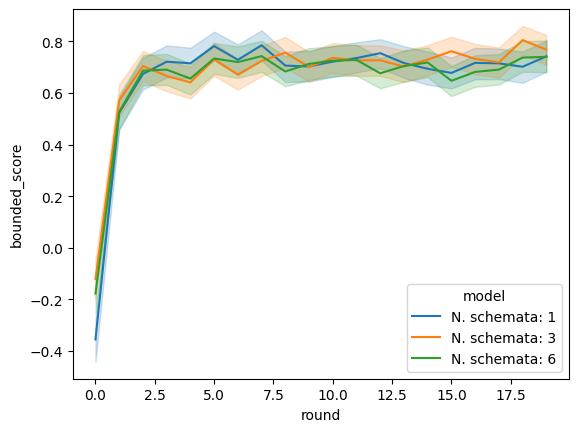

In [ ]:
sns.lineplot(
    data=df, 
    x='round', 
    y='bounded_score', 
    hue='model'
)

In [ ]:
gm = GetMeasurements(
    data=df, measures=['bounded_efficiency', 'gini_index']
)
data = gm.get_measurements()
data.head(2)

,model,threshold,num_agents,id_sim,bounded_efficiency,gini_index
0,N. schemata: 1,0.25,4,dc647c26-a0a6-11f1-90ac-beb3bfa57af2,0.80,0.015625
1,N. schemata: 1,0.25,4,dc676fda-a0a6-11f1-90ac-beb3bfa57af2,0.95,0.007576


<Axes: xlabel='gini_index', ylabel='bounded_efficiency'>

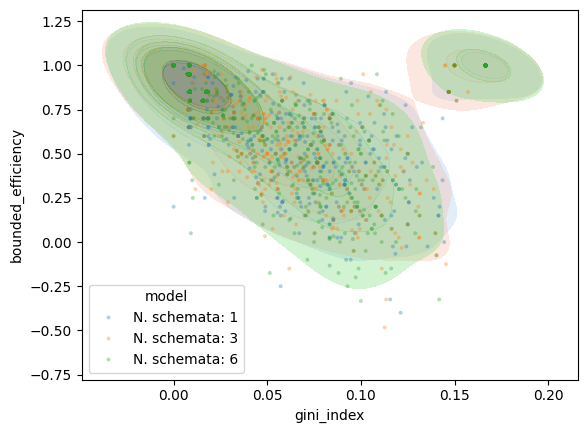

In [ ]:
sns.kdeplot(
    data=data,
    x='gini_index',
    y='bounded_efficiency',
    hue='model',
    fill=True,
    alpha=0.3,
    levels=6,
    thresh=0.05,
    legend=False,
)
ax = sns.scatterplot(
    data=data,
    x='gini_index',
    y='bounded_efficiency',
    hue='model',
    s=8,
    alpha=0.35,
    edgecolor='none',
    linewidth=0,
)
ax.legend(title='Num. schemata')